In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [65]:
df = pd.read_csv(r'C:\Users\gunav\OneDrive\Desktop\Project\patient_visits.csv')
pd.set_option('display.max.columns',10)
pd.set_option('display.max.rows',200)

In [5]:
df

,visit_id,patient_id,visit_date,date_of_birth,patient_age,patient_sex,icd_code,cpt_code
0,V000001,PT00001,3/15/2022,7/22/1956,66,Male,I10,12345
1,V000002,PT00002,4/22/2022,11/5/1982,39,Female,E11.9,23456
2,V000003,PT00003,5/10/2022,2/14/1978,44,Male,J45.909,34567
3,V000004,PT00004,1/18/2023,9/2/2004,57,Female,N39.0,45678
4,V000005,PT00005,7/30/2023,3/19/1948,75,Male,I25.110,56789
...,...,...,...,...,...,...,...,...
195,V000018,PT00018,9/9/2024,12/3/1977,46,Female,I10,98011
196,V000019,PT00019,5/25/2022,7/21/1995,28,Male,J02.9,21004
197,V000020,PT00020,7/12/2023,11/2/2004,38,Female,E78.0,26009
198,V000021,PT00021,4/3/2024,4/8/1969,55,Male,I10,52018


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   visit_id       200 non-null    object
 1   patient_id     200 non-null    object
 2   visit_date     200 non-null    object
 3   date_of_birth  200 non-null    object
 4   patient_age    200 non-null    int64 
 5   patient_sex    200 non-null    object
 6   icd_code       200 non-null    object
 7   cpt_code       200 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 12.6+ KB


In [10]:
df.isnull().sum()

visit_id         0
patient_id       0
visit_date       0
date_of_birth    0
patient_age      0
patient_sex      0
icd_code         0
cpt_code         0
dtype: int64

# Group patients into simple age bands (0–17, 18–39, 40–64, 65+).

# Create a count for each age Range and visualize it (probably with a Bar Chart)

In [163]:
labels = ['0-17','18-39','40-64','65+']
df['age_group'] = pd.cut(df['patient_age'] , bins = [0,18,40,65,100] , labels=labels)

# Count how many times each ICD code appears.

In [165]:
 age_group_count = df.groupby('age_group')['patient_age'].count().sort_values().reset_index(name = 'totalcount_groupedage')

C:\Users\gunav\AppData\Local\Temp\ipykernel_22136\3017242278.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_count = df.groupby('age_group')['patient_age'].count().sort_values().reset_index(name = 'totalcount_groupedage')


,age_group,totalcount_groupedage
0,Young,0
1,Senior,27
2,Adult,66
3,Middl Age,107


Text(0.5, 1.0, 'Group patients into simple age bands')

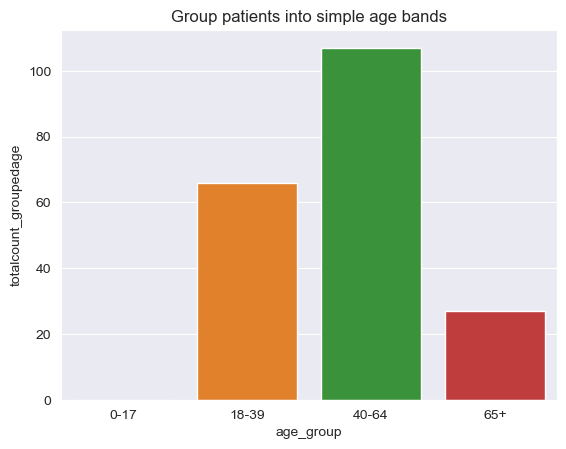

In [166]:
sns.barplot ( age_group_count ,x = 'age_group' , y = 'totalcount_groupedage',hue = 'age_group' )
sns.set_style('darkgrid')
plt.title('Group patients into simple age bands')

In [167]:
counts = df['age_group'].value_counts().sort_index()

In [168]:
counts

age_group
0-17       0
18-39     66
40-64    107
65+       27
Name: count, dtype: int64

# Identify the top 10 diagnoses overall.

# Break down top diagnoses by:

# Age band , Sex

In [198]:
 top_10_icd =  df['icd_code'].value_counts().nlargest(10).reset_index(name = 'count_icd')

In [199]:
 top_10_icd

,icd_code,count_icd
0,I10,19
1,J45.909,11
2,N39.0,11
3,E11.9,10
4,M54.5,10
5,E78.5,10
6,F32.9,9
7,K21.9,9
8,I25.10,9
9,G43.909,8


Text(0.5, 1.0, 'Top 10 icd_code by visit')

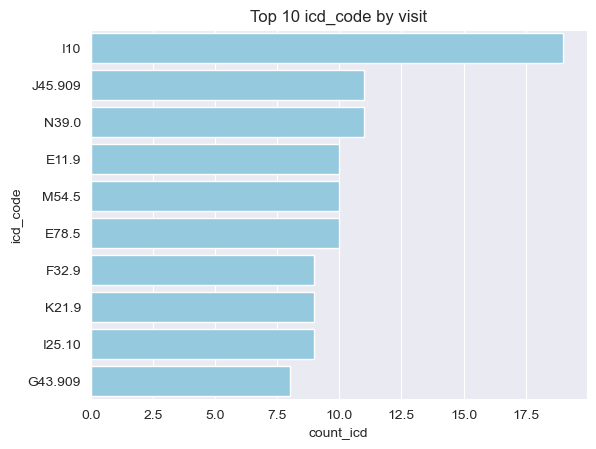

In [271]:
sns.barplot (  top_10_icd, y = 'icd_code' , x = 'count_icd' ,color= 'skyblue' )
sns.set_style('darkgrid')
plt.title('Top 10 icd_code by visit')

In [202]:
top_10_list =  df['icd_code'].value_counts().nlargest(10).index.tolist()

In [240]:
df_top10_icd = df[df['icd_code'].isin(top_10_list)].iloc[:10]

In [241]:
df_top10_icd[['icd_code','patient_sex','age_group']]

,icd_code,patient_sex,age_group
0,I10,Male,65+
1,E11.9,Female,18-39
2,J45.909,Male,40-64
3,N39.0,Female,40-64
5,F32.9,Female,18-39
6,M54.5,Female,18-39
7,K21.9,Male,40-64
8,E78.5,Female,40-64
10,I10,Female,40-64
16,G43.909,Female,40-64


Text(0.5, 1.0, 'Top 10 icd_code with age_group')

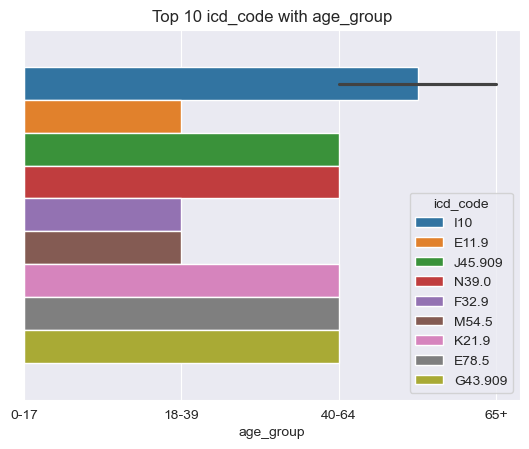

In [257]:
sns.barplot ( df_top10_icd , x = 'age_group' , hue = 'icd_code' )
sns.set_style('darkgrid')
plt.title('Top 10 icd_code with age_group')

In [244]:
grouped_df = df_top10_icd.groupby(['icd_code', 'patient_sex']).size().unstack()

# Count total diagnosis events per patient.

In [259]:
diagonises_count_patient = df.groupby('icd_code')['icd_code'].value_counts().reset_index(name ='Count_of_diagonises').sort_values(by = 'Count_of_diagonises' ,ascending =False)

In [260]:
diagonises_count_patient

,patient_id,icd_code,Count_of_diagonises
0,PT00001,I10,9
1,PT00002,E11.9,9
2,PT00003,J45.909,8
29,PT00008,M54.5,6
32,PT00009,E78.5,4
4,PT00004,I25.10,4
15,PT00006,N39.0,3
96,PT00017,G43.909,3
9,PT00005,K21.9,3
30,PT00008,F32.9,2


# Find the average number of visits per patient.

In [99]:
average_visits = df.groupby('patient_id')['visit_id'].count().mean()

In [100]:
print(f"The average number of visits per patient is: {average_visits}")

The average number of visits per patient is: 4.761904761904762


# Identify “high utilizers” (patients with 4+ visits) 

In [111]:
visits_per_patient = df.groupby('patient_id')['visit_id'].count()

In [267]:
high_utilizers = visits_per_patient[visits_per_patient >= 4]

In [115]:
print("High utilizers (patients with 4+ visits):")
print(high_utilizers)

High utilizers (patients with 4+ visits):
patient_id
PT00001    9
PT00002    9
PT00003    9
PT00004    9
PT00005    9
PT00006    9
PT00007    9
PT00008    9
PT00009    9
PT00010    9
PT00011    9
PT00012    9
PT00013    9
PT00014    9
PT00015    9
PT00016    9
PT00017    9
PT00018    9
PT00019    8
PT00020    8
Name: visit_id, dtype: int64


In [117]:
print(f"\nTotal number of high utilizers: {len(high_utilizers)}")


Total number of high utilizers: 20


# Get the percentage of patients who are high utilizers

In [118]:
total_patients = len(visits_per_patient)
percentage = (len(high_utilizers) / total_patients) * 100
print(f"Percentage of patients who are high utilizers: {percentage:.2f}%")

Percentage of patients who are high utilizers: 47.62%


# Rank CPT codes by frequency to see which procedures are performed most often.

In [281]:
cpt_frequency = df['cpt_code'].value_counts().reset_index(name = 'no_of_cpt_code')

In [282]:
cpt_frequency 

,cpt_code,no_of_cpt_code
0,99213,7
1,99204,6
2,99214,6
3,90123,4
4,23456,4
5,99215,4
6,99212,4
7,12345,4
8,89012,4
9,78901,4
